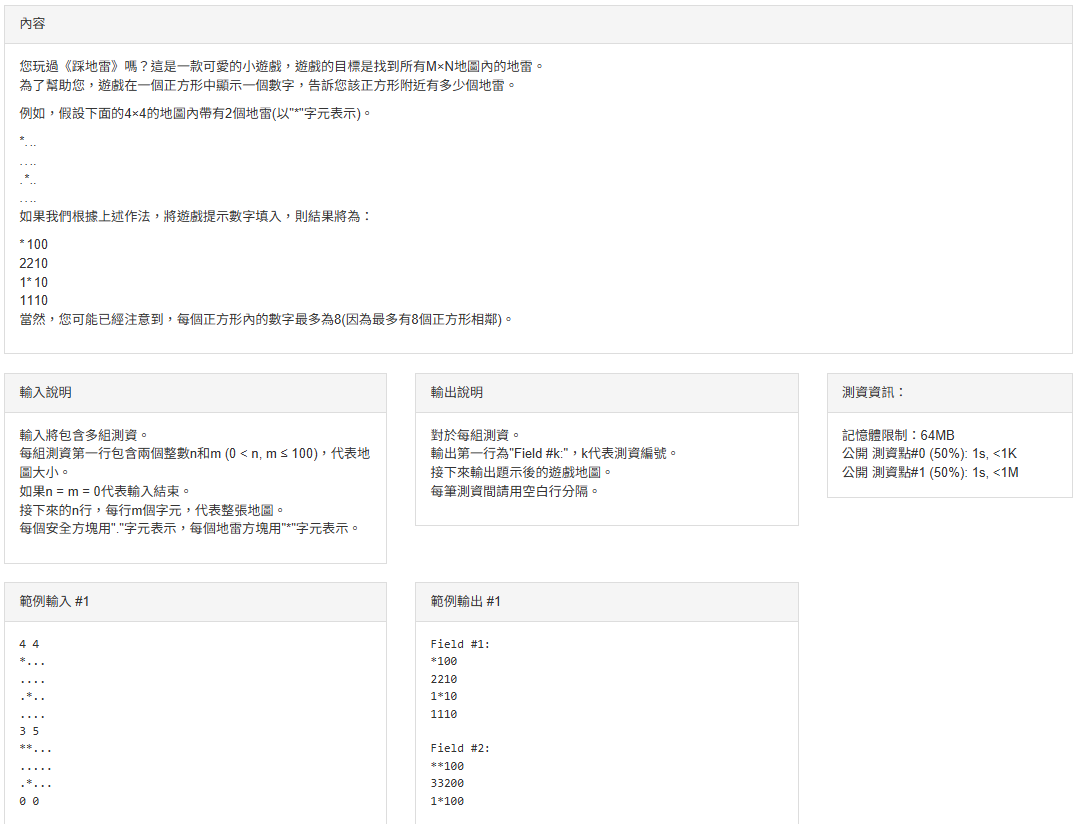

In [ ]:
### 自寫 ###

field = 0 # 計算場次，print會用到

while True:
	size = input() #把size那行讀入
	a, b = map(int, size.split())
	if a == 0 and b == 0:
		break
	
	## 計算field次數，並由field次數控制換行
	field += 1
	if field > 1:
		print("")
	
	## 將地雷座標與全部座標以tuple形式儲存於list
	mines = []
	all = []
	for i in range(a):
		mine = input()
		for j, symbol in enumerate(mine):
			all.append((i, j))
			if symbol == "*":
				mines.append((i, j))
	
	## 建立字典以tuple為key，次數為對應值，*另行處理
	dic = {}
	for x in all:
		dic[x] = 0 #先將所有座標值存為0次
		for y in mines:
			if x[0] == y[0] and x[1] == y[1]: #判斷tuple(座標)是否與地雷座標相同
				dic[x] = "*"
			elif abs(x[0] - y[0]) <= 1 and abs(x[1] - y[1]) <= 1 and dic[x] != "*": #dic[x] != "*"是為了避免確定是地雷了又被數值覆蓋
				dic[x] += 1
	
	print(f"Field #{field}:")
	for index, z in enumerate(all):
		print(dic[z], end="") #end=""代表什麼都不新增，意同於將字元串接
		
		if (index + 1) % b == 0:
			print() #預設結尾為end="\n"，即直接換行

In [ ]:
### GPT版本 ###
field = 0

while True:
    rows, cols = map(int, input().split())

    if rows == 0 and cols == 0:
        break

    mine_map = [input() for _ in range(rows)] #將每行讀入，簡短寫法
    field += 1

    if field > 1:
        print()

    print(f"Field #{field}:")

    for row in range(rows):
        result = "" #可以直接由字串連接

        for col in range(cols):
            if mine_map[row][col] == "*":
                result += "*"
            else:
                count = 0

                ## 針對非地雷的座標周遭掃描地雷數量
                for neighbor_row in range(max(0, row - 1), min(rows, row + 2)):
                    for neighbor_col in range(max(0, col - 1), min(cols, col + 2)):
                        if mine_map[neighbor_row][neighbor_col] == "*":
                            count += 1

                result += str(count) #數字型態記得轉成字串

        print(result)

### Note
1. 字典用法:
    - 型態:dic = {key:value}
    - dic[x] = 0 對x賦值0，記得是用中括號，若後續改寫其他值，則0會被覆蓋。
    - dic[x] += 1 可以做累加。
2. print用法:
    - print(end="") 不換行不加空格，可直接接下一個字串。
    - print(end="\n") 直接換行，意同於print()。
    - print(end=" ") 可以空白連接下一個字串。
3. 字串可以利用"+"更簡易地連接所有字串。